In [16]:
%load_ext autoreload
%autoreload 2

import cupy as cp
import math
import matplotlib.pyplot as plt
from utils.data_loader import ImagenetteDataLoader
from model import Network

import pickle
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the Data

In [2]:
train_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="train",
    target_size=(96, 96)
)

len(train_loader), train_loader.get_image_shape()

(9469, (3, 96, 96))

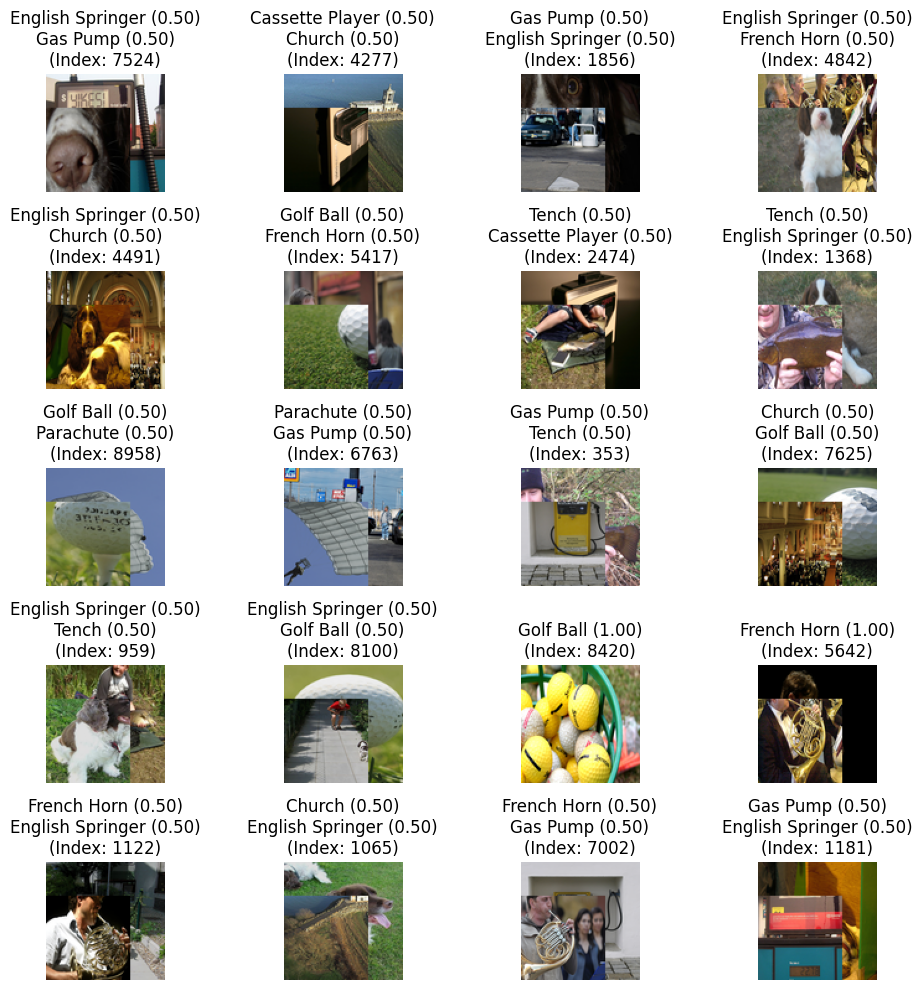

In [3]:
random_indices = cp.random.randint(0, len(train_loader), size=20)
train_loader.plot_batch(
    random_indices.get().tolist(),
    figsize=(10, 10),
    random_crop_chance=1.0,
    flip_chance=0.5,
    color_jitter_chance=0.85,
    cut_mix_chance=1
)

In [4]:
test_loader = ImagenetteDataLoader(
    root_path="input/imagenette2",
    split="val",
    target_size=(96, 96)
)

len(test_loader), test_loader.get_image_shape()

(3925, (3, 96, 96))

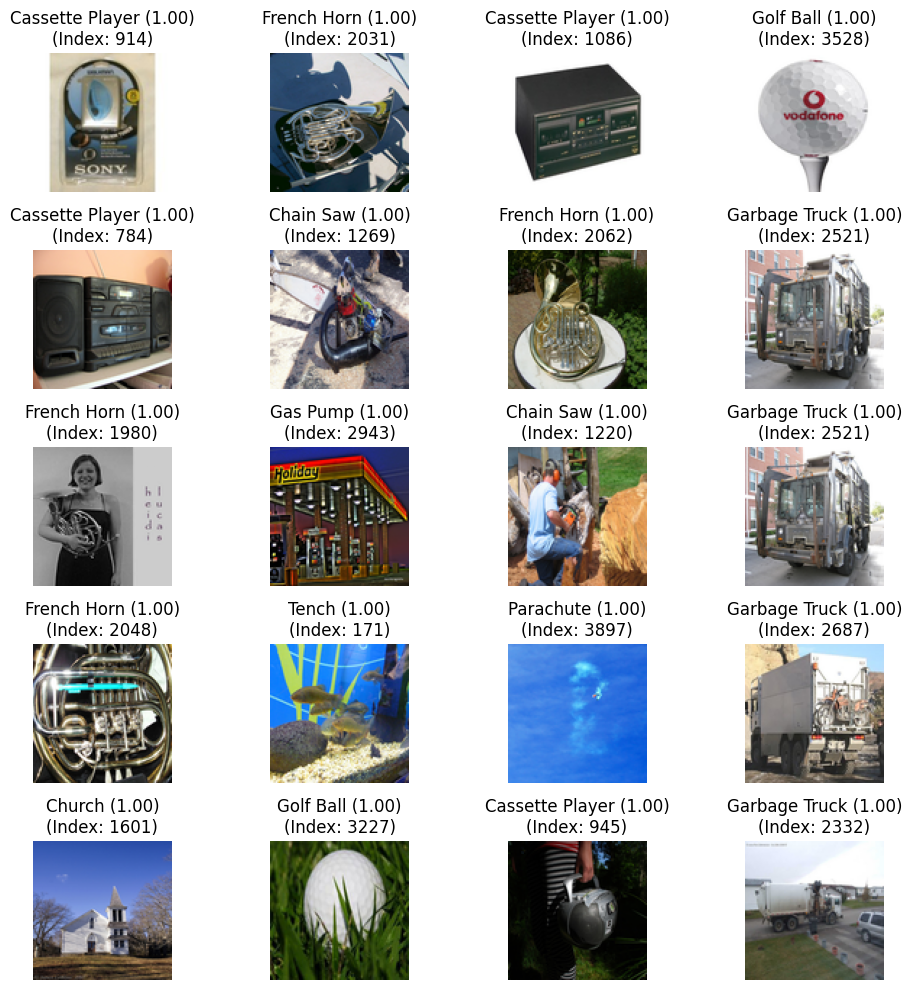

In [5]:
random_indices = cp.random.randint(0, len(test_loader), size=20)
test_loader.plot_batch(
    random_indices.get().tolist(),
    figsize=(10, 10)
)

## Building the Model

In [6]:
feature_layers = [
    {"type": "ReLUConv", "num_filters": 24, "num_channels": 3, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "ReLUConv", "num_filters": 24, "num_channels": 24, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 48, "num_channels": 24, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "ReLUConv", "num_filters": 48, "num_channels": 48, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 72, "num_channels": 48, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "ReLUConv", "num_filters": 72, "num_channels": 72, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "MaxPool", "pool_height": 2, "pool_width": 2, "stride": 2},
    {"type": "ReLUConv", "num_filters": 96, "num_channels": 72, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "ReLUConv", "num_filters": 96, "num_channels": 96, "kernel_height": 3, "kernel_width": 3, "padding": 1, "stride": 1},
    {"type": "GlobalAvgPool"},
    {"type": "Flatten"}
 ]

warmup_input, _ = train_loader.load_batch(indices=[0], normalize=True)
feature_extractor = Network(layer_definitions=feature_layers)
classifier_input_size = int(feature_extractor.forward(input=warmup_input)[-1].shape[1])

layer_definitions = feature_layers + [
    {"type": "Softmax", "input_size": classifier_input_size, "num_neurons": 10},
]

network = Network(layer_definitions=layer_definitions)

In [7]:
network.describe()

Network Architecture

Layer 1: ReluConvLayer
  Filters Shape: (24, 3, 3, 3) | Biases Shape: (24,)
  Parameters: 672

Layer 2: ReluConvLayer
  Filters Shape: (24, 24, 3, 3) | Biases Shape: (24,)
  Parameters: 5,208

Layer 3: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 4: ReluConvLayer
  Filters Shape: (48, 24, 3, 3) | Biases Shape: (48,)
  Parameters: 10,416

Layer 5: ReluConvLayer
  Filters Shape: (48, 48, 3, 3) | Biases Shape: (48,)
  Parameters: 20,784

Layer 6: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 7: ReluConvLayer
  Filters Shape: (72, 48, 3, 3) | Biases Shape: (72,)
  Parameters: 31,176

Layer 8: ReluConvLayer
  Filters Shape: (72, 72, 3, 3) | Biases Shape: (72,)
  Parameters: 46,728

Layer 9: MaxPoolLayer
  Pool Shape: (2, 2) | Stride: 2

Layer 10: ReluConvLayer
  Filters Shape: (96, 72, 3, 3) | Biases Shape: (96,)
  Parameters: 62,304

Layer 11: ReluConvLayer
  Filters Shape: (96, 96, 3, 3) | Biases Shape: (96,)
  Parameters: 83,040

Layer 12: GlobalAvgPo

In [8]:
print("Input Shape:", warmup_input.shape)
_ = network.forward(input=warmup_input, print_shapes=True)

Input Shape: (1, 3, 96, 96)
Layer 0 Output Shape: (1, 24, 96, 96)
Layer 1 Output Shape: (1, 24, 96, 96)
Layer 2 Output Shape: (1, 24, 48, 48)
Layer 3 Output Shape: (1, 48, 48, 48)
Layer 4 Output Shape: (1, 48, 48, 48)
Layer 5 Output Shape: (1, 48, 24, 24)
Layer 6 Output Shape: (1, 72, 24, 24)
Layer 7 Output Shape: (1, 72, 24, 24)
Layer 8 Output Shape: (1, 72, 12, 12)
Layer 9 Output Shape: (1, 96, 12, 12)
Layer 10 Output Shape: (1, 96, 12, 12)
Layer 11 Output Shape: (1, 96, 1, 1)
Layer 12 Output Shape: (1, 96)
Layer 13 Output Shape: (1, 10)


## Building the Train/Eval Loops

In [9]:
def evaluate_model(model, data_loader, batch_size):
    total_loss = 0.0
    correct_predictions = 0
    num_samples = 0
    num_batches = (len(data_loader) + batch_size - 1) // batch_size

    for x_batch, y_batch in data_loader.iter_batches(
        batch_size=batch_size,
        normalize=True,
        one_hot=True,
        shuffle=False
    ):
        outputs = model.forward(input=x_batch)
        y_pred = outputs[-1]

        total_loss += model.cce_loss(y_pred=y_pred, y_true=y_batch).item()

        predicted_labels = cp.argmax(y_pred, axis=1)
        true_labels = cp.argmax(y_batch, axis=1)

        correct_predictions += cp.sum(predicted_labels == true_labels).item()
        num_samples += x_batch.shape[0]

    avg_loss = total_loss / num_batches
    accuracy = correct_predictions / num_samples

    return avg_loss, accuracy

In [10]:
def train_model(model, 
                train_loader, 
                test_loader, 
                batch_size=16, 
                epochs=10, 
                base_learning_rate=0.003, 
                min_learning_rate=0.0001, 
                weight_decay_lambda=0.0,
                stop_early_patience=10):
    train_num_batches = (len(train_loader) + batch_size - 1) // batch_size
    total_steps = epochs * train_num_batches
    global_step = 0

    best_model = model.clone()
    best_model_accuracy = float("-inf")

    epochs_without_improvement = 0

    epoch_summaries = []

    for epoch in range(epochs):
        total_loss = 0.0

        for _, (x_batch, y_batch) in enumerate(
            train_loader.iter_batches(
                batch_size=batch_size, 
                normalize=True, 
                one_hot=True, 
                shuffle=True, 
                random_crop_chance=1.0,
                flip_chance=0.5,
                color_jitter_chance=0.85,
                cut_mix_chance=0.5
            ), start=1
        ):
            learning_rate = min_learning_rate + 0.5 * (base_learning_rate - min_learning_rate) * (1 + math.cos(math.pi * global_step / total_steps))

            outputs = model.forward(input=x_batch)
            y_pred = outputs[-1]

            error = y_pred - y_batch
            loss = model.cce_loss(y_pred=y_pred, y_true=y_batch).item()
            total_loss += loss

            model.backward(output_error=error, batch_size=x_batch.shape[0])
            model.update_parameters(learning_rate=learning_rate, weight_decay_lambda=weight_decay_lambda)

            global_step += 1

        train_loss = total_loss / train_num_batches
        test_loss, test_accuracy = evaluate_model(
            model=model, 
            data_loader=test_loader, 
            batch_size=batch_size
        )

        if test_accuracy > best_model_accuracy:
            best_model = model.clone()
            best_model_accuracy = test_accuracy
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        epoch_summary = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "test_accuracy": test_accuracy
        }
        epoch_summaries.append(epoch_summary)
        print(epoch_summary)
        
        if stop_early_patience and epochs_without_improvement >= stop_early_patience:
            print(f"Stopping early after {epoch + 1} epochs due to no improvement.")
            break

    return best_model, epoch_summaries

## Training the Model

In [11]:
batch_size = 32
epochs = 250
base_learning_rate = 0.01
min_learning_rate = 0.0001
weight_decay_lambda = 0.0005
stop_early_patience = 20

best_model, epoch_summaries = train_model(
    model=network,
    train_loader=train_loader,
    test_loader=test_loader,
    batch_size=batch_size,
    epochs=epochs,
    base_learning_rate=base_learning_rate,
    min_learning_rate=min_learning_rate,
    weight_decay_lambda=weight_decay_lambda,
    stop_early_patience=stop_early_patience
)

{'epoch': 1, 'train_loss': 2.1367632550802695, 'test_loss': 1.9716223070228993, 'test_accuracy': 0.30828025477707005}
{'epoch': 2, 'train_loss': 1.9925687597543693, 'test_loss': 1.8404311952706685, 'test_accuracy': 0.36280254777070065}
{'epoch': 3, 'train_loss': 1.9139341982189992, 'test_loss': 1.9132072322289346, 'test_accuracy': 0.35082802547770703}
{'epoch': 4, 'train_loss': 1.849365886486828, 'test_loss': 1.7086036851789284, 'test_accuracy': 0.41630573248407643}
{'epoch': 5, 'train_loss': 1.7993639507871357, 'test_loss': 1.6872971123046936, 'test_accuracy': 0.4099363057324841}
{'epoch': 6, 'train_loss': 1.7532815112913225, 'test_loss': 1.6806681230476106, 'test_accuracy': 0.41656050955414015}
{'epoch': 7, 'train_loss': 1.7146903043240043, 'test_loss': 1.5929453389408836, 'test_accuracy': 0.46726114649681527}
{'epoch': 8, 'train_loss': 1.6643482480630027, 'test_loss': 1.5309328098192572, 'test_accuracy': 0.49936305732484076}
{'epoch': 9, 'train_loss': 1.638389254397304, 'test_loss':

In [17]:
model_path = "best_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"Saved best_model to {model_path}")

Saved best_model to best_model.pkl


## Evaluating the Model

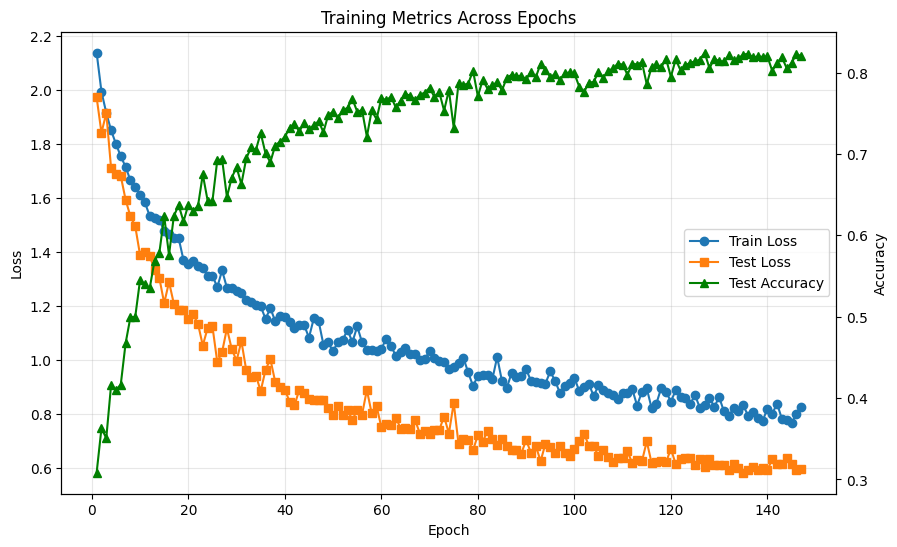

In [12]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_losses = [summary["train_loss"] for summary in epoch_summaries]
test_losses = [summary["test_loss"] for summary in epoch_summaries]
test_accuracies = [summary["test_accuracy"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

line1 = ax1.plot(epochs_plot, train_losses, marker="o", label="Train Loss")
line2 = ax1.plot(epochs_plot, test_losses, marker="s", label="Test Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
line3 = ax2.plot(epochs_plot, test_accuracies, marker="^", color="green", label="Test Accuracy")
ax2.set_ylabel("Accuracy")

lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training Metrics Across Epochs")
plt.show()

In [13]:
train_loss, train_accuracy = evaluate_model(
    model=best_model, 
    data_loader=train_loader, 
    batch_size=batch_size
)

print(f"Final Train Loss: {train_loss:.6f} | Final Train Accuracy: {train_accuracy:.4f}")

Final Train Loss: 0.411536 | Final Train Accuracy: 0.8907


In [14]:
test_loss, test_accuracy = evaluate_model(
    model=best_model, 
    data_loader=test_loader, 
    batch_size=batch_size
)

print(f"Final Test Loss: {test_loss:.6f} | Final Test Accuracy: {test_accuracy:.4f}")

Final Test Loss: 0.604638 | Final Test Accuracy: 0.8245
